# **CLUSTERING**
Clustering is a type of unsupervised learning that classifies data into specific trends according to specific division criteria using only explanatory variables. The algorithms we have learned so far are called supervised learning algorithms, which create models in which explanatory variables can explain the objective variable. Clustering does not require an objective variable, and classifies data into multiple classes using only explanatory variables.

Now, we will implement the clustering algorithm, but we will understand the detailed calculation methods as we implement it.
# K-MEANS SCRATCH
We will create a K-means class from scratch. We will implement the algorithm using only a minimum number of libraries such as NumPy.

# Artificial Datasets for Clustering
We provide code to create an artificial dataset for experimenting with clustering.

This make_blobs function also outputs the correct label, but we won't use it this time. To make it clear that we won't use it, we receive it with an underscore (_).


In [1]:
import numpy as np
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=0.5, shuffle=True, random_state=0)

# Center Point
The center (central point or centroid) of a cluster is the average value of all the points (elements) that belong to that cluster.

# Problem 1: Determine the initial value of the center point
Create a code that determines the initial values of $K$ center points $\mu_1$ through $\mu_K$ from the input data, where $K$ is the specified number of clusters.

The simplest way to determine the initial values is to randomly select $K$ data points from $X_n$. We implement it for now.

The learning results of K-means are affected by the initial value of the central point $\mu$. Therefore, during learning, calculations are performed with multiple initial values.

In [2]:
class ScratchKMeans:
    def __init__(self, n_clusters=4):
        self.n_clusters = n_clusters
        self.myu = None
        self.best_sse = float('inf')
        self.record_myu = None
        self.record_cluster = None

    def initialize_centroids(self, X, random_state=0):
        np.random.seed(random_state)
        self.myu = X[np.random.choice(len(X), size=self.n_clusters, replace=False)]
        print("Initial centroids:\n", self.myu)
# Usage
Scratchkmeans = ScratchKMeans(n_clusters=4)
Scratchkmeans.initialize_centroids(X, random_state=0)

Initial centroids:
 [[-0.565433    3.65813966]
 [ 1.60161834  0.92363636]
 [ 1.35678894  4.36462484]
 [-1.26041884  7.46644456]]


# Problem 2: Creating a function to calculate SSE
Create a function to calculate the within-cluster sum of squared errors (SSE).

The goal of K-means is to find $r_{nk}$ and $\mu_k$ that minimize this SSE. The function that calculates this SSE is used to decide which clustering result to finally adopt from the clustering results calculated with multiple initial values.

$$SSE = \sum_{n=1}^{N}\sum_{k=1}^{K}r_{nk}||X_n - \mu_k||^2$$ 

$n$ : data point index

$k$ : cluster index

$X_n$ : $n$th data point

$\mu_k$ : $k$th center point

$r_{nk}$ : 1 if data point $X_n$ belongs to cluster $k$, 0 otherwise

Repeatedly assigning clusters and moving center points
K-means learning is based on repeating the following two phases:

For a fixed center point $\mu_k$, choose a cluster assignment $r_{nk}$ that minimizes $SSE$.
For a fixed cluster assignment $r_{nk}$, we choose a center point $\mu_k$ that minimizes $SSE$.
The first center point $\mu_k$ is the initial value created in Problem 1.

Let's take a look at them in order.

In [3]:
import numpy as np
from sklearn.datasets import make_blobs

# Generate sample data
X, _ = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=0.5, random_state=0)

class ScratchKMeans:
    def __init__(self, n_clusters=4):
        self.n_clusters = n_clusters
        self.myu = None
        self.best_sse = float('inf')
        self.record_myu = None
        self.record_cluster = None

    def initialize_centroids(self, X, random_state=0):
        np.random.seed(random_state)
        self.myu = X[np.random.choice(len(X), size=self.n_clusters, replace=False)]
        print("Initial centroids:\n", self.myu)

    def assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.myu, axis=2)
        return np.argmin(distances, axis=1)

    def calc_sse(self, X, cluster_labels):
        sse = 0
        for i in range(len(X)):
            cluster_idx = int(cluster_labels[i])
            sse += np.sum((X[i] - self.myu[cluster_idx]) ** 2)
        if sse < self.best_sse:
            self.best_sse = sse
            self.record_myu = self.myu.copy()
            self.record_cluster = cluster_labels.copy()
        return sse

# Instantiate the model
kmeans = ScratchKMeans(n_clusters=4)

# Run K-Means steps
kmeans.initialize_centroids(X)
cluster_labels = kmeans.assign_clusters(X)
sse = kmeans.calc_sse(X, cluster_labels)

print(f"SSE: {sse}")

Initial centroids:
 [[-0.565433    3.65813966]
 [ 1.60161834  0.92363636]
 [ 1.35678894  4.36462484]
 [-1.26041884  7.46644456]]
SSE: 84.33640249455568


# Cluster
It is a collection of data points that are grouped together based on some kind of similarity.

The process of assigning a data point to a cluster is simple: go through all the clusters, then calculate the distance to the corresponding cluster's center point. If the distance is smaller (closer) than the previous one, it will be assigned to the nearest cluster. Each cluster will have a center point that is the average of the values in that cluster. The final step is to repeat this process.

# Problem 3: Allocation to clusters
Write code that assigns every data point $X_n$ to the closest center point $\mu_k$.

In K-menas , closeness means that the Euclidean distance between two points is small. The Euclidean distance is calculated using the Pythagorean theorem, and for vectors $p,q$, it can be expressed by the following formula:

$$||q - p|| = \sqrt{(q - p)(q - p)}$$
NumPy provides this function, np.linalg.normso use it.

numpy.linalg.norm — NumPy v1.17 Manual

We are minimizing the SSE after fixing the center point $\mu_k$, but there is no need to calculate the SSE itself.

In [4]:
class KMeans:
    def __init__(self, n_clusters=4):
        self.n_clusters = n_clusters
        self.myu = None
        self.best_sse = float('inf')
        self.record_myu = None
        self.record_cluster = None

    def initialize_centroids(self, X, random_state=0):
        np.random.seed(random_state)
        self.myu = X[np.random.choice(len(X), size=self.n_clusters, replace=False)]

    def calc_sse(self, X, cluster_labels):
        sse = 0
        for i in range(len(X)):
            cluster_idx = int(cluster_labels[i])
            sse += np.sum((X[i] - self.myu[cluster_idx]) ** 2)
        if sse < self.best_sse:
            self.best_sse = sse
            self.record_myu = self.myu.copy()
            self.record_cluster = cluster_labels.copy()
        return sse

    def _update_cluster(self, X_with_labels):
        """
        Assigns each data point to the nearest cluster center.
        Assumes the last column of X_with_labels is for cluster labels.
        """
        for i in range(len(X_with_labels)):
            min_dist = float('inf')
            for j in range(self.n_clusters):
                dist = np.linalg.norm(X_with_labels[i, :-1] - self.myu[j])
                if dist < min_dist:
                    min_dist = dist
                    X_with_labels[i, -1] = j

In [5]:
from sklearn.datasets import make_blobs

# Create dataset
X, _ = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=0.5, shuffle=True, random_state=0)

# Add one column to store cluster assignments
X_with_labels = np.hstack([X, np.zeros((X.shape[0], 1))])


In [6]:
kmeans = KMeans(n_clusters=4)
kmeans.initialize_centroids(X, random_state=0)
kmeans._update_cluster(X_with_labels)

# Print first 10 assignments
print(X_with_labels[:10])

[[ 0.72086751  3.71347124  2.        ]
 [-1.89468423  7.96898545  3.        ]
 [ 1.35678894  4.36462484  2.        ]
 [ 1.05374379  4.49286859  2.        ]
 [ 1.59141542  4.90497725  2.        ]
 [ 0.78260667  4.15263595  2.        ]
 [-1.95751686  3.87291474  0.        ]
 [-0.77354537  7.87923564  3.        ]
 [ 0.12313498  5.27917503  2.        ]
 [-1.43284669  7.71577043  3.        ]]


# Problem 4: Moving the center point
Write code that moves the center point $\mu_k$ to the mean value (centroid) of all data points $X_n$ that are assigned to the $k$th cluster.

We are minimizing the SSE while fixing the cluster assignment $r_{nk}$, but there is no need to calculate the SSE itself.

In [7]:
class KMeans:
    def __init__(self, n_clusters=4):
        self.n_clusters = n_clusters
        self.myu = None
        self.best_sse = float('inf')
        self.record_myu = None
        self.record_cluster = None

    def initialize_centroids(self, X, random_state=0):
        np.random.seed(random_state)
        self.myu = X[np.random.choice(len(X), size=self.n_clusters, replace=False)]

    def _update_cluster(self, X_with_labels):
        for i in range(len(X_with_labels)):
            min_dist = float('inf')
            for j in range(self.n_clusters):
                dist = np.linalg.norm(X_with_labels[i, :-1] - self.myu[j])
                if dist < min_dist:
                    min_dist = dist
                    X_with_labels[i, -1] = j

    def _update_myu(self, X_with_labels):
        for j in range(self.n_clusters):
            cluster_points = X_with_labels[X_with_labels[:, -1] == j, :-1]
            if len(cluster_points) > 0:
                self.myu[j] = np.mean(cluster_points, axis=0)

In [8]:
# Create the KMeans object
kmeans = KMeans(n_clusters=4)

# Generate dataset and add label column
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=0.5, shuffle=True, random_state=0)
X_with_labels = np.hstack([X, np.zeros((X.shape[0], 1))])

# Initialize and run one K-means iteration
kmeans.initialize_centroids(X, random_state=0)
kmeans._update_cluster(X_with_labels)
kmeans._update_myu(X_with_labels)

# Problem 5: Repetition
Write code that trains by repeatedly assigning to clusters and moving center points. This will stop if any of the following conditions are met:

- The iteration reaches the specified number of times. 
- The sum of the differences between the center point $\mu_k$ and the center of gravity is less than the specified tolerance.

In [9]:
class KMeans:
    def __init__(self, n_clusters=4):
        self.n_clusters = n_clusters
        self.myu = None
        self.best_sse = float('inf')
        self.record_myu = None
        self.record_cluster = None

    def initialize_centroids(self, X, random_state=0):
        np.random.seed(random_state)
        self.myu = X[np.random.choice(len(X), size=self.n_clusters, replace=False)]

    def _update_cluster(self, X_with_labels):
        for i in range(len(X_with_labels)):
            min_dist = float('inf')
            for j in range(self.n_clusters):
                dist = np.linalg.norm(X_with_labels[i, :-1] - self.myu[j])
                if dist < min_dist:
                    min_dist = dist
                    X_with_labels[i, -1] = j

    def _update_myu(self, X_with_labels):
        for j in range(self.n_clusters):
            cluster_points = X_with_labels[X_with_labels[:, -1] == j, :-1]
            if len(cluster_points) > 0:
                self.myu[j] = np.mean(cluster_points, axis=0)
    def calc_sse(self, X_with_labels):
        sse = 0
        for i in range(len(X_with_labels)):
            cluster_idx = int(X_with_labels[i, -1])
            sse += np.sum((X_with_labels[i, :-1] - self.myu[cluster_idx]) ** 2)

        if sse < self.best_sse:
            self.best_sse = sse
            self.record_myu = self.myu.copy()
            self.record_cluster = X_with_labels[:, -1].copy()

    def fit(self, X, max_iter=100, tol=1e-4, n_init=10, verbose=False):
        """
        Train K-means by repeating assignment and center update.
        Stops when either max_iter is reached or centroid movement is below tol.
        """
        self.n_iter = max_iter
        self.n_init = n_init
        self.verbose = verbose
        self.best_sse = float('inf')

        for i in range(self.n_init):
            # Initialize centroids randomly
            self.myu = X[np.random.choice(len(X), size=self.n_clusters, replace=False)]

             # Add column for cluster labels
            cluster = np.zeros(len(X))
            X_cluster = np.concatenate([X, cluster.reshape(-1, 1)], axis=1)

            for j in range(self.n_iter):
                prev_myu = self.myu.copy()

                # Cluster assignment and center update
                self._update_cluster(X_cluster)
                self._update_myu(X_cluster)
                self.calc_sse(X_cluster)

                # Stopping criterion: check centroid movement
                centroid_shift = np.sum(np.linalg.norm(self.myu - prev_myu, axis=1))
                if centroid_shift < tol:
                    if self.verbose:
                        print(f"Initialization: {i}, Iteration: {j}, Early Stop - Centroid shift {centroid_shift:.6f}")
                    break

                if self.verbose:
                    print(f"Initialization: {i}, Iteration: {j}, SSE: {self.best_sse:.6f}")


In [10]:
from sklearn.datasets import make_blobs

# Generate data
X, _ = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=0.5, random_state=0)

# Train model
kmeans = KMeans(n_clusters=4)
kmeans.fit(X, max_iter=100, tol=1e-4, n_init=5, verbose=True)

Initialization: 0, Iteration: 0, SSE: 267.592412
Initialization: 0, Iteration: 1, SSE: 237.955686
Initialization: 0, Iteration: 2, SSE: 221.549026
Initialization: 0, Iteration: 3, SSE: 194.923608
Initialization: 0, Iteration: 4, SSE: 115.845030
Initialization: 0, Iteration: 5, SSE: 53.297001
Initialization: 0, Iteration: 6, SSE: 48.633783
Initialization: 0, Iteration: 7, Early Stop - Centroid shift 0.000000
Initialization: 1, Iteration: 0, SSE: 48.633783
Initialization: 1, Iteration: 1, SSE: 48.633783
Initialization: 1, Iteration: 2, SSE: 48.633783
Initialization: 1, Iteration: 3, SSE: 48.633783
Initialization: 1, Iteration: 4, SSE: 48.633783
Initialization: 1, Iteration: 5, Early Stop - Centroid shift 0.000000
Initialization: 2, Iteration: 0, SSE: 48.633783
Initialization: 2, Iteration: 1, SSE: 48.633783
Initialization: 2, Iteration: 2, SSE: 48.633783
Initialization: 2, Iteration: 3, Early Stop - Centroid shift 0.000000
Initialization: 3, Iteration: 0, SSE: 48.633783
Initialization: 3

# Problem 6: Calculate with different initial values
Create a code that repeats the calculation of problem 5 by changing the initial value a specified number of times. The number of times is specified in the argument n_init in the template.

The final learning result will be the one with the smallest SSE among multiple calculations, so we retain the central point $\mu_k$ at that time.

In [11]:
import numpy as np

class ScratchKMeans():
    def __init__(self, n_clusters=2, n_init=20, n_iter=100, verbose=False):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.n_iter = n_iter
        self.verbose = verbose
        self.best_sse = float('inf')

    def fit(self, X, tol=1e-4):
        for i in range(self.n_init):
            # Initialize centroids
            np.random.seed(i)  # for reproducibility across runs
            self.myu = X[np.random.choice(len(X), size=self.n_clusters, replace=False)]

            # Add column for cluster labels
            cluster = np.zeros(len(X))
            X_cluster = np.concatenate([X, cluster.reshape(-1, 1)], axis=1)

            for j in range(self.n_iter):
                prev_myu = self.myu.copy()
                self._update_cluster(X_cluster)
                self._update_myu(X_cluster)
                self._calc_sse(X_cluster)

                # Check for convergence
                shift = np.sum(np.linalg.norm(self.myu - prev_myu, axis=1))
                if shift < tol:
                    if self.verbose:
                        print(f"[Init {i}] Early stop at iteration {j}: shift={shift:.6f}")
                    break

                if self.verbose:
                    print(f"[Init {i}] Iteration {j} | SSE: {self.best_sse:.4f}")

        # Final assignment with best result
        self.myu = self.record_myu
        self.labels_ = self.record_cluster.astype(int)

    def _update_cluster(self, X):
        for i in range(len(X)):
            min_dist = float('inf')
            for j in range(self.n_clusters):
                dist = np.linalg.norm(X[i, :-1] - self.myu[j])
                if dist < min_dist:
                    min_dist = dist
                    X[i, -1] = j

    def _update_myu(self, X):
        for j in range(self.n_clusters):
            cluster_points = X[X[:, -1] == j, :-1]
            if len(cluster_points) > 0:
                self.myu[j] = np.mean(cluster_points, axis=0)

    def _calc_sse(self, X):
        sse = 0
        for i in range(len(X)):
            cluster_idx = int(X[i, -1])
            sse += np.sum((X[i, :-1] - self.myu[cluster_idx]) ** 2)
        if sse < self.best_sse:
            self.best_sse = sse
            self.record_myu = self.myu.copy()
            self.record_cluster = X[:, -1].copy()

In [12]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=0.5, random_state=0)

model = ScratchKMeans(n_clusters=4, n_init=10, n_iter=100, verbose=True)
model.fit(X)
print("Best SSE:", model.best_sse)
print("Final centroids:\n", model.myu)
print("Cluster assignments:\n", model.labels_)

[Init 0] Iteration 0 | SSE: 57.6690
[Init 0] Iteration 1 | SSE: 48.6338
[Init 0] Early stop at iteration 2: shift=0.000000
[Init 1] Iteration 0 | SSE: 48.6338
[Init 1] Iteration 1 | SSE: 48.6338
[Init 1] Iteration 2 | SSE: 48.6338
[Init 1] Iteration 3 | SSE: 48.6338
[Init 1] Iteration 4 | SSE: 48.6338
[Init 1] Iteration 5 | SSE: 48.6338
[Init 1] Iteration 6 | SSE: 48.6338
[Init 1] Iteration 7 | SSE: 48.6338
[Init 1] Early stop at iteration 8: shift=0.000000
[Init 2] Iteration 0 | SSE: 48.6338
[Init 2] Iteration 1 | SSE: 48.6338
[Init 2] Early stop at iteration 2: shift=0.000000
[Init 3] Iteration 0 | SSE: 48.6338
[Init 3] Iteration 1 | SSE: 48.6338
[Init 3] Iteration 2 | SSE: 48.6338
[Init 3] Early stop at iteration 3: shift=0.000000
[Init 4] Iteration 0 | SSE: 48.6338
[Init 4] Iteration 1 | SSE: 48.6338
[Init 4] Iteration 2 | SSE: 48.6338
[Init 4] Iteration 3 | SSE: 48.6338
[Init 4] Iteration 4 | SSE: 48.6338
[Init 4] Early stop at iteration 5: shift=0.000000
[Init 5] Iteration 0 | SS

# Problem 7: Estimation
When estimating which cluster new data belongs to, we do the same thing as in the first phase of training.

For the data points $X_n$ and the center points $\mu_k$ determined by training, select $r_{nk}$ that minimizes $SSE$.
Specifically,

Assign the data point $X_n$ to the nearest $\mu_k$.

In [13]:
import numpy as np

class ScratchKMeans():
    def __init__(self, n_clusters=2, n_init=20, n_iter=100, verbose=False):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.n_iter = n_iter
        self.verbose = verbose
        self.best_sse = float('inf')  # initialize best SSE

    def fit(self, X, tol=1e-4):
        for i in range(self.n_init):
            # Initialize centroids
            np.random.seed(i)  # Reproducible initial centroids
            self.myu = X[np.random.choice(len(X), size=self.n_clusters, replace=False)]

            # Add column for cluster labels
            cluster = np.zeros(len(X))
            X_cluster = np.concatenate([X, cluster.reshape(-1, 1)], axis=1)

            for j in range(self.n_iter):
                prev_myu = self.myu.copy()
                self._update_cluster(X_cluster)
                self._update_myu(X_cluster)
                sse = self._calc_sse(X_cluster)

                # Check if this is the best run
                if sse < self.best_sse:
                    self.best_sse = sse
                    self.record_myu = self.myu.copy()
                    self.record_cluster = X_cluster[:, -1].copy()

                # Convergence check
                shift = np.sum(np.linalg.norm(self.myu - prev_myu, axis=1))
                if shift < tol:
                    if self.verbose:
                        print(f"[Init {i}] Early stop at iteration {j}: shift={shift:.6f}")
                    break

                if self.verbose:
                    print(f"[Init {i}] Iteration {j} | SSE: {sse:.4f}")

        # Final assignment with best result
        self.myu = self.record_myu
        self.labels_ = self.record_cluster.astype(int)

    def _update_cluster(self, X):
        for i in range(len(X)):
            min_dist = float('inf')
            for j in range(self.n_clusters):
                dist = np.linalg.norm(X[i, :-1] - self.myu[j])
                if dist < min_dist:
                    min_dist = dist
                    X[i, -1] = j

    def _update_myu(self, X):
        for j in range(self.n_clusters):
            cluster_points = X[X[:, -1] == j, :-1]
            if len(cluster_points) > 0:
                self.myu[j] = np.mean(cluster_points, axis=0)

    def _calc_sse(self, X):
        sse = 0
        for i in range(len(X)):
            cluster_id = int(X[i, -1])
            sse += np.sum((X[i, :-1] - self.myu[cluster_id]) ** 2)
        return sse

    def predict(self, X):
        y_pred = np.zeros(len(X))
        for i in range(len(X)):
            min_dist = float('inf')
            for j in range(self.n_clusters):
                dist = np.linalg.norm(X[i] - self.record_myu[j])
                if dist < min_dist:
                    min_dist = dist
                    y_pred[i] = j
        return y_pred.astype(int)

In [14]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Create synthetic dataset
X, _ = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=0.5, random_state=0)
X_train, X_valid = train_test_split(X, train_size=0.8, random_state=42)

# Train model
clf = ScratchKMeans(n_clusters=4, n_init=5, n_iter=100, verbose=True)
clf.fit(X_train)

# Predict
y_valid_pred = clf.predict(X_valid)
print("Predicted clusters:", y_valid_pred)

[Init 0] Iteration 0 | SSE: 41.7373
[Init 0] Iteration 1 | SSE: 39.5277
[Init 0] Early stop at iteration 2: shift=0.000000
[Init 1] Iteration 0 | SSE: 205.4090
[Init 1] Iteration 1 | SSE: 190.8453
[Init 1] Iteration 2 | SSE: 182.0651
[Init 1] Iteration 3 | SSE: 132.6849
[Init 1] Iteration 4 | SSE: 103.9174
[Init 1] Iteration 5 | SSE: 103.2252
[Init 1] Iteration 6 | SSE: 102.4041
[Init 1] Iteration 7 | SSE: 102.0185
[Init 1] Early stop at iteration 8: shift=0.000000
[Init 2] Iteration 0 | SSE: 105.7474
[Init 2] Iteration 1 | SSE: 104.1932
[Init 2] Iteration 2 | SSE: 103.7411
[Init 2] Iteration 3 | SSE: 102.5911
[Init 2] Early stop at iteration 4: shift=0.000000
[Init 3] Iteration 0 | SSE: 115.7588
[Init 3] Iteration 1 | SSE: 103.2718
[Init 3] Early stop at iteration 2: shift=0.000000
[Init 4] Iteration 0 | SSE: 102.9158
[Init 4] Early stop at iteration 1: shift=0.000000
Predicted clusters: [2 1 3 3 1 1 1 0 3 2 1 0 3 0 2 2 1 1 3 3]


# Problem 8: Implementing the elbow method
The elbow method is a technique for determining the optimal number of clusters. In K-means, the number of center points $k$ must be determined manually, but one way to do this is the elbow method. We create code to consider the number of center points $k$ using the elbow method.

It displays a line graph with SSE on the vertical axis and the number of clusters $k$ on the horizontal axis. To do this, we obtain SSE from the K-means instance.

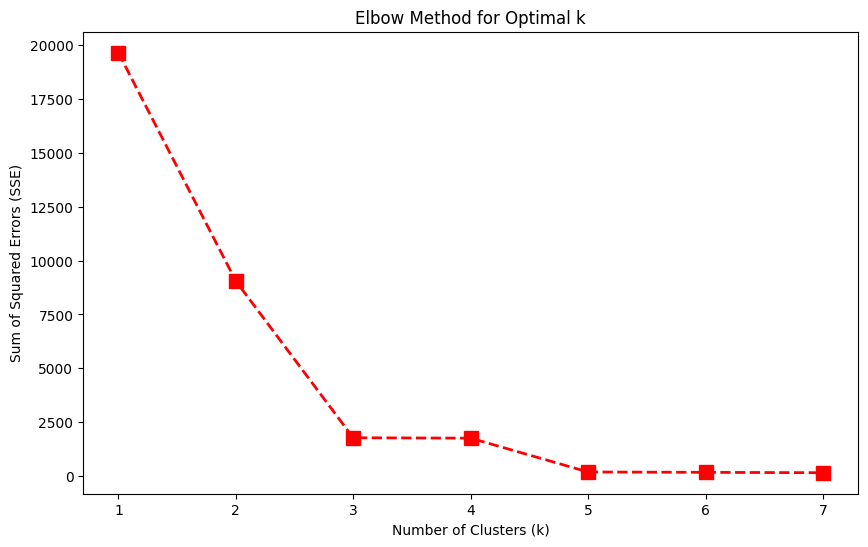

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Create synthetic dataset
X, _ = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=0.6, random_state=42)

# Dictionary to store SSE for each value of k
elbow = {}

# Test different numbers of clusters from 1 to 7
for k in range(1, 8):
    model = ScratchKMeans(n_clusters=k, n_init=5, n_iter=100, verbose=False)
    model.fit(X)
    elbow[k] = model.best_sse

# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(list(elbow.keys()), list(elbow.values()), 'rs--', markersize=10, linewidth=2)
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.xticks(range(1, 8))
plt.grid(False)
plt.show()

In the above graph, the optimal number of clusters is 5.
The reason is that the decrease in SSE (sum of squared residuals) levels off after the number of clusters is 5. In other words, the error in the clustering results is reduced.
Also, the name of the elbow method comes from the fact that the optimal number of clusters is the point where your elbow is when you bend your arm.

# Problem 9: (Advanced) Silhouette figure
Another thing that can help determine $k$ is the silhouette plot. Please write some code to display the silhouette plot.

I have prepared the code to display the figure using Matplotlib. Please provide the following:

silhouette_vals: ndarray of shape(n_samples,) and silhouette coefficients of each data point

silhouette_avg: float, mean value of silhouette coefficient

y_km: An ndarray of shape(n_samples,) and the cluster label name of each data point

cluster_labels: list, a list of cluster label names

n_clusters: int, number of clusters

The silhouette coefficient $s_n$ for the $n$th data point can be calculated using the following formula: Implement this formula and check the silhouette plot.
$$s_n = \frac{b_n - a_n}{max(b_n, a_n)}$$
$a_n$ : Cohesion. The average distance between a point and other points in the same cluster.

$b_n$ : Discrepancy. The average distance between a point and all data points in the nearest other cluster.

Ideally, when the discrepancy $b$ is large and the cohesion $a$ is small, the silhouette coefficient $s$ will be close to 1.

In [16]:
def silhouette_score(X, labels, n_clusters):
    silhouette_vals = np.zeros(len(X))
    
    for i in range(len(X)):
        own_cluster = labels[i]
        other_clusters = [k for k in range(n_clusters) if k != own_cluster]
        
        # Points in the same cluster
        same_cluster = X[labels == own_cluster]
        a = np.mean([np.linalg.norm(X[i] - point) for point in same_cluster if not np.array_equal(point, X[i])])
        
        # Distance to other clusters
        b = float('inf')
        for other in other_clusters:
            other_cluster = X[labels == other]
            dist = np.mean([np.linalg.norm(X[i] - point) for point in other_cluster])
            if dist < b:
                b = dist

        # Handle the rare case of a singleton cluster
        if len(same_cluster) == 1:
            silhouette_vals[i] = 0
        else:
            silhouette_vals[i] = (b - a) / max(a, b)
    
    return silhouette_vals, np.mean(silhouette_vals)

In [17]:
# Train ScratchKMeans
model = ScratchKMeans(n_clusters=4, n_init=5, n_iter=100, verbose=False)
model.fit(X)

# Get predicted cluster labels
y_km = model.predict(X)

# Calculate silhouette scores
silhouette_vals, silhouette_avg = silhouette_score(X, y_km, n_clusters=4)

# Get unique cluster labels
cluster_labels = np.unique(y_km)

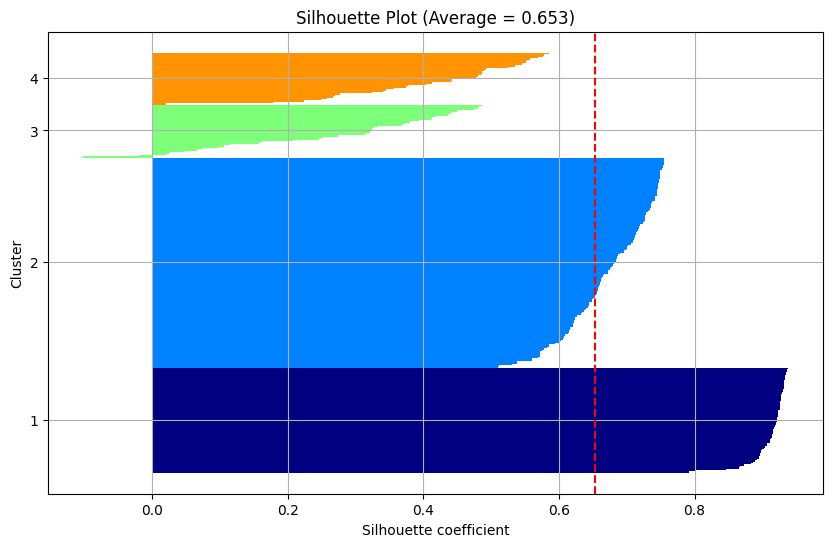

In [18]:
from matplotlib import cm
import matplotlib.pyplot as plt

# Initialize y-axis boundaries
y_ax_lower, y_ax_upper = 0, 0
yticks = []

# Create the plot
plt.figure(figsize=(10, 6))

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / len(cluster_labels))
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2)
    y_ax_lower += len(c_silhouette_vals)

# Red line for average silhouette score
plt.axvline(silhouette_avg, color="red", linestyle="--")
plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')
plt.title(f'Silhouette Plot (Average = {silhouette_avg:.3f})')
plt.grid(True)
plt.show()

The red dashed line shows the average silhoutte score of 0.653.

# **Cluster Analysis**
# Wholesaler Data Analysis
To demonstrate the use of clustering, we will use the Wholesale customers Data Set. Wholesale customers data.csv is data collected from customers by a wholesaler in Lisbon, Portugal. The data shows how many euros each customer spends on milk and groceries per year. The customers are retail stores and restaurants. We will leave out the Region" Channel and use K-means on the amount data.
# Dimensionality reduction
There are six features related to the amount, but we will reduce the dimensions in order to visualize them. For this, we will use the sample code for PCA using scikit-learn.


Cumulative explained variance ratio: [0.45961362 0.86478588 0.93481597 0.97883941 0.99386152 1.        ]


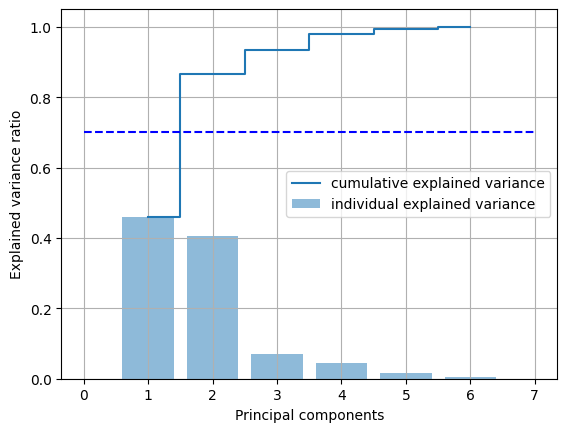

In [19]:
# Corrected version
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data (only amount features)
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv')
X = data[['Fresh', 'Milk', 'Grocery', 'Frozen','Detergents_Paper', 'Delicassen']].values

# Perform PCA on X (6 features)
pca = PCA(n_components=None)
pca = pca.fit(X)
var_exp = pca.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)
print("Cumulative explained variance ratio:", cum_var_exp)

# Plot
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1, len(cum_var_exp)+1), cum_var_exp, where='mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.hlines(0.7, 0, len(var_exp)+1, colors="blue", linestyles='dashed')
plt.legend(loc='best')
plt.grid()
plt.show()


# Problem 10: Selecting the number of clusters k
Choose the number of clusters $k$ that you think is optimal. You can use the elbow method or silhouette diagrams, and your choice will also be influenced by how you want to use the data later. After making your choice, explain why you chose it.

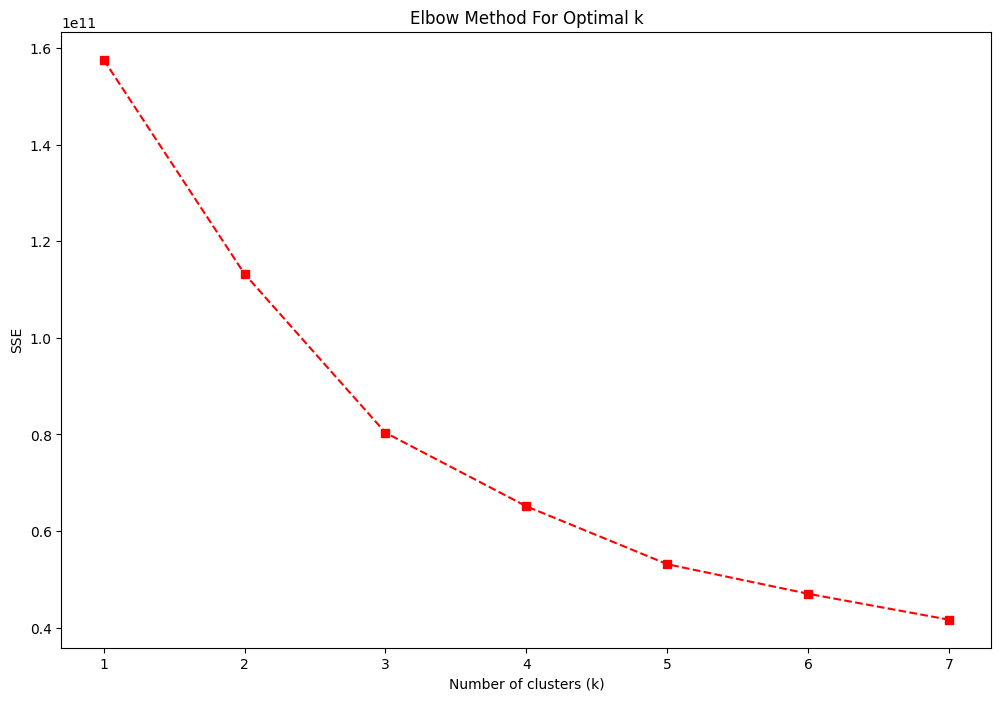

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'elbow' is a dictionary with k as keys and SSE as values
elbow = {}
for k in range(1, 8):
    model = ScratchKMeans(n_clusters=k, n_init=5, n_iter=100, verbose=False)
    model.fit(X)
    elbow[k] = model.best_sse

plt.figure(figsize=(12, 8))
plt.plot(list(elbow.keys()), list(elbow.values()), 'rs--')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method For Optimal k')
plt.show()

In the previous text, the optimal number of clusters output by the elbow method was the number of clusters when the decrease in SSE (sum of squared residuals) leveled off.
However, in this case, you can see that it is difficult to determine the optimal number of clusters using the elbow method. So, let's make a judgment based on the use of this data.
Let's say the purpose of this analysis is to "analyze customer information, understand the characteristics of good customers and customers, and use this information to develop future measures." In that case, you will realize that if you divide the data into too many clusters, you will not have enough manpower and will not be able to develop useful measures, but if you divide the data into too few clusters, it will not be good either.
Therefore: Problem 11

# Question 11: Comparison with known groups
RegionThese are known groups, but Channelwere not used in K-means. Please explain how the clusters differ from these known groups. First, visualize each one.

In [21]:
X = data[['Fresh', 'Milk', 'Grocery', 'Frozen','Detergents_Paper', 'Delicassen']].values
X

# Comparison with groups
clf = ScratchKMeans(n_clusters=4,n_init=5,n_iter=100,verbose=False)
clf.fit(X)
pred = clf.predict(X)
summary_df = pd.DataFrame({'pred':pred,'Region':data['Region'],'Channel':data['Channel'],})
summary_df

,pred,Region,Channel
0,3,3,2
1,3,3,2
2,3,3,2
3,3,3,1
4,2,3,2
...,...,...,...
435,2,3,1
436,2,3,1
437,1,3,2
438,3,3,1


In [22]:
# Comparison with region
pd.pivot_table(summary_df, index='Region', columns='pred',values='Channel', aggfunc=len).fillna(0).astype(int)


pred,0,1,2,3
Region,,,,
1,0,15,10,52
2,1,11,4,31
3,4,58,45,209


In [23]:
# Comparison with Channel
pd.pivot_table(summary_df, index='Channel', columns='pred',values='Region', aggfunc=len).fillna(0).astype(int)


pred,0,1,2,3
Channel,,,,
1,0,8,51,239
2,5,76,8,53


# Question 12: Useful information for wholesalers
We will look at summary statistics for each cluster using the data before preprocessing. Also, use K-means on the data that was reduced in dimension by PCA, but try using the six features as is, or using only some of the features and refer to the results of the comparison with known groups.

In [24]:
# Original data is assigned classified clusters
data['cluster'] = pred

In [25]:
summary = data.groupby(['Channel', 'Region', 'cluster']).agg(['mean', 'max', 'min'])
summary

Fresh                         Milk         \
                                mean     max    min          mean    max   
Channel Region cluster                                                     
1       1      1         4357.500000    5909   2806  17146.000000  23527   
               2        34673.500000   56083  22096   4639.100000  11487   
               3         8633.680851   23257    514   3141.680851  17972   
        2      2        29443.000000   32717  25977   7568.666667  16784   
               3         9515.440000   22321      3   1672.520000   3696   
        3      1         8392.500000   18291    694   8416.666667  21858   
               2        38465.052632  112151  23632   6141.236842  43950   
               3         8480.491018   22686      3   2705.904192  18664   
2       1      1         4152.923077   12119     18  12910.846154  28326   
               3         7922.400000   20782   2427   5254.200000   7097   
        2      0         8565.000000    8565   8565   4980.000000   4980   
               1         4024.181818   11223    161  12790.818182  25071   
               2        27082.000000   27082  27082   6817.000000   6817   
               3         9765.500000   16823   2886   3688.166667   6243   
        3      0        29862.500000   44466  16117  53080.750000  73498   
               1         5336.173077   26373     37  12319.288462  36423   
               2        29915.571429   40721  22615   7430.571429  12319   
               3        10142.095238   21465     23   5906.333333  10769   

                                    Grocery                      Frozen  \
                          min          mean    max    min          mean   
Channel Region cluster                                                    
1       1      1        10765  14618.500000  15538  13699   5764.500000   
               2          489   5944.100000  16966   1495   5640.300000   
               3          258   3167.319149  10817    489   2480.425532   
        2      2         2335   8123.333333  13626   2464  22094.666667   
               3          333   3948.160000  11593   1330   3783.080000   
        3      1         1266  15164.333333  21042  10518   2198.666667   
               2          286   5606.815789  20170    471   6991.789474   
               3           55   3090.155689  12400      3   2950.455090   
2       1      1         6154  22763.307692  39694  11364   2057.615385   
               3         2527   7314.400000  10391   5265   3953.000000   
        2      0         4980  67298.000000  67298  67298    131.000000   
               1         3688  17367.181818  26839   8852   1111.090909   
               2         6817  10790.000000  10790  10790   1365.000000   
               3          928   6845.500000   9965   2743   2592.166667   
        3      0        38369  60015.750000  92780  32114   3262.250000   
               1         1275  19198.557692  45828   9345   1448.711538   
               2         3916   9711.428571  13792   4955   1730.857143   
               3         1124   8780.523810  14982   4523   1390.190476   

                                    Detergents_Paper                \
                          max   min             mean    max    min   
Channel Region cluster                                               
1       1      1        10155  1374      3329.000000   5828    830   
               2        18711   432       508.500000    967    111   
               3         7683    91       943.361702   4762      5   
        2      2        60869  2369       594.333333   1272    140   
               3        15601   264       469.320000   1679     15   
        3      1         5373    25      3916.666667   6907    241   
               2        36534   127       737.973684   4948     10   
               3        35009    47       685.311377   4595      3   
2       1      1         6746    61     10316.461538  19410   4797   
               3  

Channel 2 spend more on Detergents_Paper and Grocery, channel 1 Spend more on Fresh, Milk, and Delicassen and region 3 customers dominate across clusters. By grouping the data using cluster, channel, and region, we revealed distinct purchasing patterns among customer types. Channel 2 tend to buy high volumes of Grocery and Detergents_Paper, especially in Region 3, suggesting the presence of wholesalers or supermarkets. In contrast, Channel 1 show strong demand for Fresh, Milk, and Delicassen, likely reflecting daily restaurant/hotel needs.

These insights can inform wholesalers to tailor pricing, delivery frequency, and product bundles. For instance, Cluster 2 customers may benefit from bulk pricing and warehouse delivery, while Cluster 1 may prefer daily logistics and promotions on perishable items. Segmenting marketing strategies by cluster can optimize both sales and customer satisfaction.

# Other Non-Hierarchical Clustering Methods
# Problem 13: (Advanced) Research into other methods
Besides K-means, which we covered here, a well-known non-hierarchical clustering method is DBSCAN , and
besides PCA, well-known dimensionality reduction methods include t -SNE and LLE .

1. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Advantages
- Does not require specifying the number of clusters beforehand (unlike K-means).

- Can find clusters of arbitrary shapes, not just spherical ones.

- Robust to outliers — it can label them as noise instead of forcing them into a cluster.

- Good for uneven cluster densities.

Disadvantages
- Parameter sensitivity: Choosing eps (radius) and min_samples can be tricky.

- Struggles in high-dimensional spaces (curse of dimensionality).

- Not ideal for clusters with varying densities — may merge or split clusters incorrectly.

2. t-SNE (t-distributed Stochastic Neighbor Embedding)

Advantages
- Excellent for visualizing high-dimensional data in 2D/3D — reveals natural clusters visually.

- Preserves local structure (neighborhood relationships) very well.

- Often shows patterns that PCA misses due to non-linearity.

Disadvantages
- Not suitable for clustering — t-SNE is for visualization only, not modeling.

- Computationally expensive and slow on large datasets.

- Not interpretable — the axes and distances don’t have real meaning.

- Results can change across runs due to randomness.

3. LLE (Locally Linear Embedding)
Advantages
- Good for preserving the local geometry of data.

- Captures nonlinear manifolds, unlike PCA which is linear.

- Deterministic results (no randomness like t-SNE).

Disadvantages
- Struggles with noisy data and outliers.

- Sensitive to the number of neighbors.

- Fails if the manifold is not well-sampled or data is too sparse.

- Does not always preserve global structure.

# Problem 14: (Advanced assignment) Using t-SNE and DBSCAN
For the Wholesale customers data, we use t-SNE to reduce the dimensionality instead of PCA, and use DBSCAN for clustering instead of K-means.

Compare the clustering results with those of PCA+kmeans by using scikit-learn for the implementation.

《Parameter Tuning》

These methods are more difficult to tune parameters for than K-means or PCA. It is important to check the meaning of the parameters by referring to papers along with the scikit-learn documentation.

t-SNE papers

DBSCAN paper

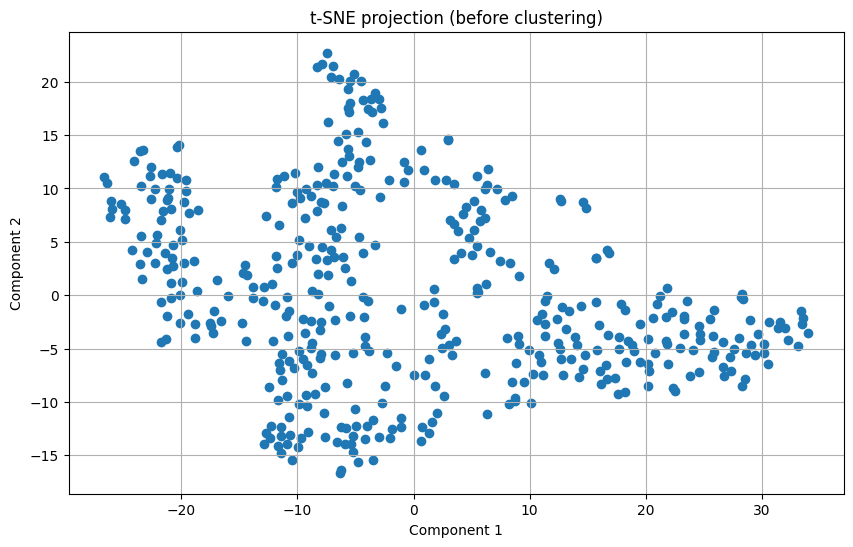

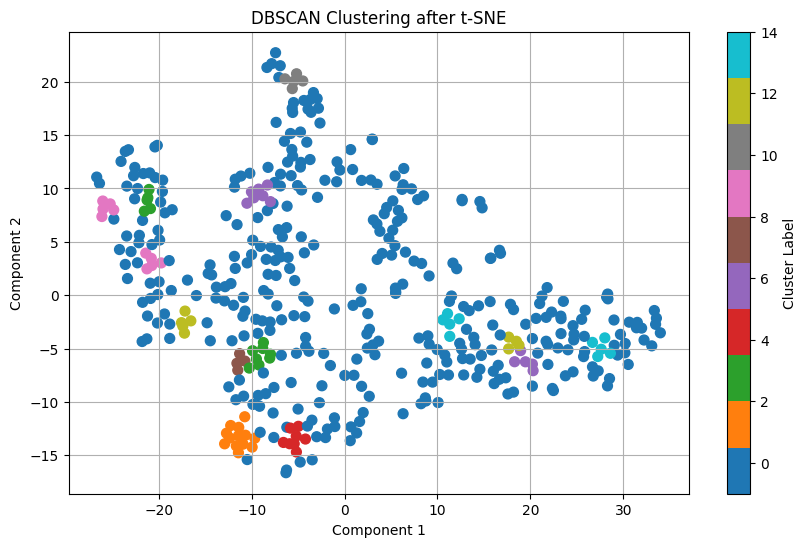

Cluster counts:
 Cluster
-1     349
 1      13
 4       8
 3       8
 0       7
 5       7
 14      5
 12      5
 6       5
 8       5
 2       5
 10      5
 13      5
 9       5
 11      4
 7       4
Name: count, dtype: int64

Comparison with Region:
 Cluster  -1    0    1    2    3    4    5    6    7    8    9    10   11   12  \
Region                                                                          
1         60    0    1    0    1    1    2    0    2    3    0    3    0    0   
2         36    0    2    1    1    1    2    0    0    0    1    0    1    1   
3        253    7   10    4    6    6    3    5    2    2    4    2    3    4   

Cluster   13   14  
Region             
1          3    1  
2          1    0  
3          1    4  

Comparison with Channel:
 Cluster  -1    0    1    2    3    4    5    6    7    8    9    10   11   12  \
Channel                                                                         
1        225    5   13    5    8    8    7    1    4

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Load data
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv'
data = pd.read_csv(url)

# Features only (excluding Region and Channel)
X = data[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].values

# Standardize features (important for t-SNE and DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Visualize t-SNE result before clustering
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.title('t-SNE projection (before clustering)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid()
plt.show()

# Apply DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)  # eps needs tuning
dbscan_labels = dbscan.fit_predict(X_tsne)

# Plot DBSCAN clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels, cmap='tab10', s=50)
plt.title('DBSCAN Clustering after t-SNE')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.colorbar(label='Cluster Label')
plt.grid()
plt.show()

# Append results for comparison
results_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
results_df['Cluster'] = dbscan_labels
results_df['Region'] = data['Region']
results_df['Channel'] = data['Channel']

# View cluster counts
print("Cluster counts:\n", results_df['Cluster'].value_counts())

# Compare with known groups
region_comparison = pd.pivot_table(results_df, index='Region', columns='Cluster', aggfunc='size', fill_value=0)
channel_comparison = pd.pivot_table(results_df, index='Channel', columns='Cluster', aggfunc='size', fill_value=0)

print("\nComparison with Region:\n", region_comparison)
print("\nComparison with Channel:\n", channel_comparison)


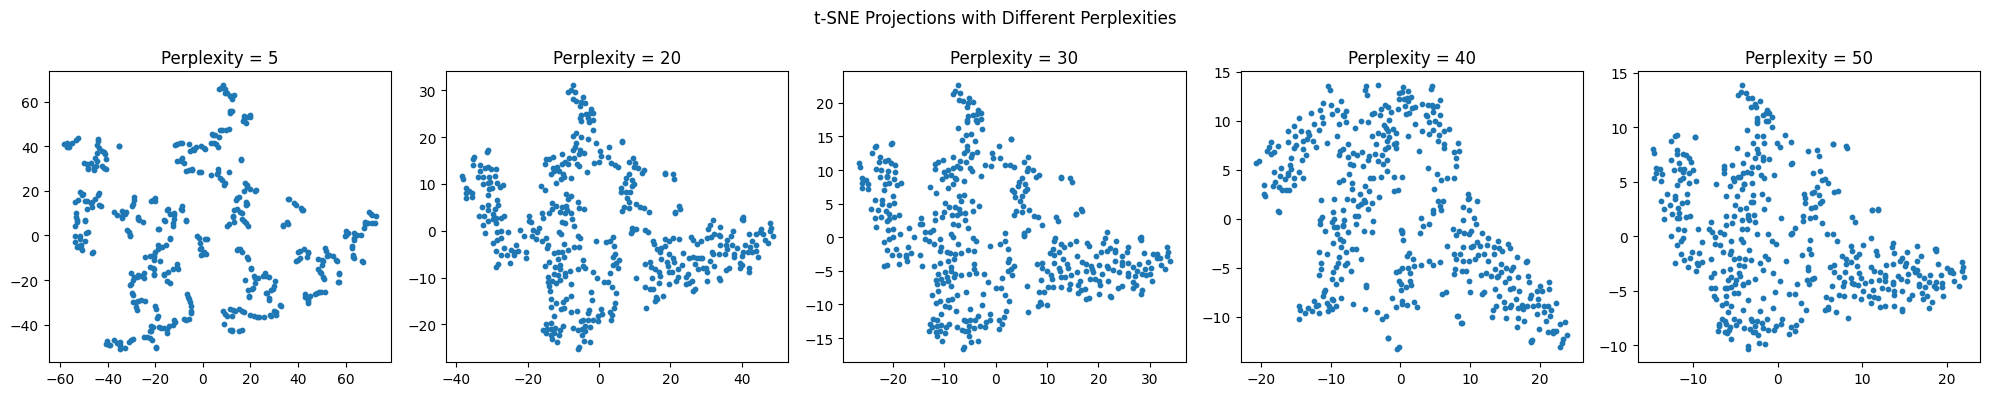

In [27]:
# t-SNE Parameter Tuning (perplexity)
from sklearn.manifold import TSNE

perplexities = [5, 20, 30, 40, 50]
fig, axs = plt.subplots(1, len(perplexities), figsize=(20, 4))

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    axs[i].scatter(X_tsne[:, 0], X_tsne[:, 1], s=10)
    axs[i].set_title(f'Perplexity = {perp}')

plt.suptitle("t-SNE Projections with Different Perplexities")
plt.tight_layout()
plt.show()


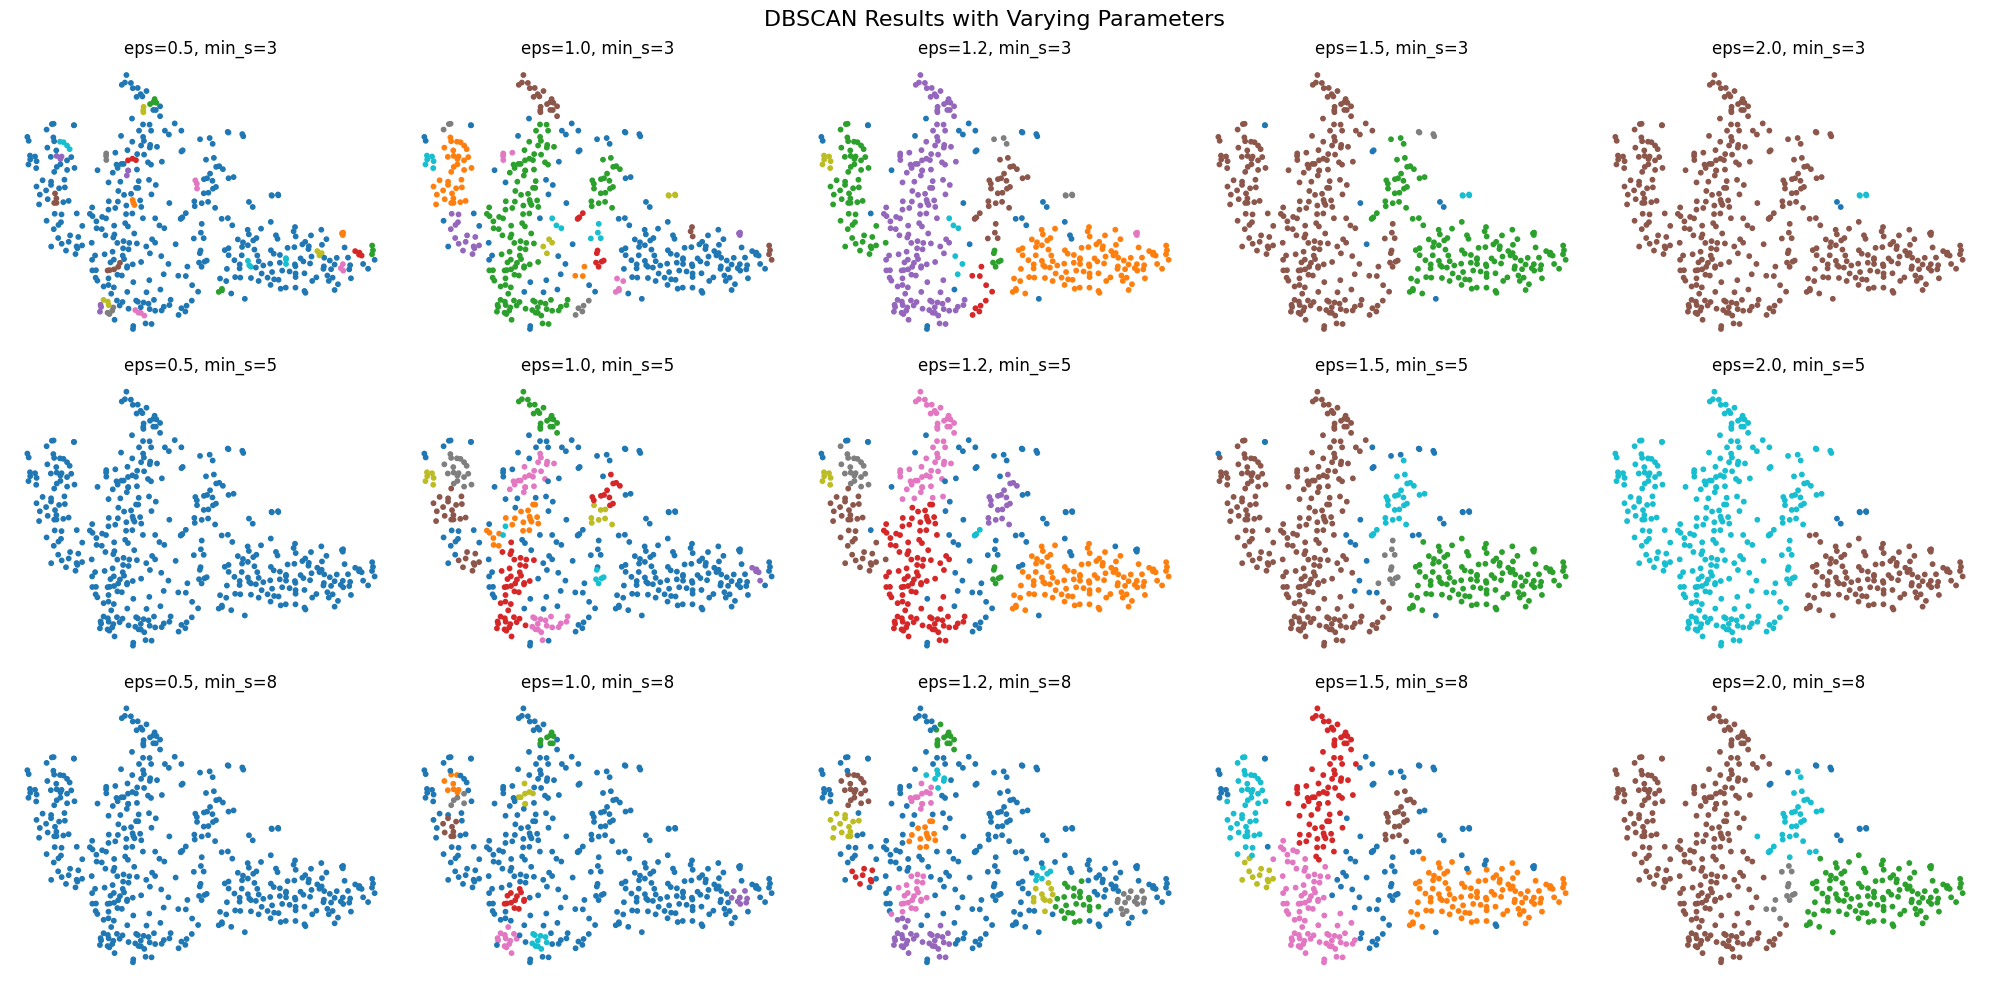

In [28]:
# DBSCAN Parameter Tuning (eps, min_samples)
from sklearn.cluster import DBSCAN

# Let's say the best t-SNE result is saved as X_tsne
eps_values = [0.5, 1.0, 1.2, 1.5, 2.0]
min_samples = [3, 5, 8]

fig, axs = plt.subplots(len(min_samples), len(eps_values), figsize=(20, 10))

for i, min_s in enumerate(min_samples):
    for j, eps in enumerate(eps_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_tsne)
        axs[i, j].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
        axs[i, j].set_title(f'eps={eps}, min_s={min_s}')
        axs[i, j].axis('off')

plt.suptitle("DBSCAN Results with Varying Parameters", fontsize=16)
plt.tight_layout()
plt.show()
